# Module 12 — Interpretability and Fairness

"Explainable AI" is usually presented as a toolbox. It is better understood as
a set of **questions**, each with a different right tool and a different
failure mode:

- *What does this model rely on overall?* → global importance
- *Why did this applicant get declined?* → local attribution
- *How does risk change with income?* → partial dependence
- *Does the model treat groups differently?* → fairness metrics
- *Would a regulator accept this?* → constraints, documentation, monitoring

Using a tool built for one of those to answer another is the most common error
in the field, and it is usually invisible.

### Learning objectives

1. Choose between coefficients, permutation importance, PDP/ICE and SHAP by
   the question being asked.
2. Diagnose and fix the correlated-features failure that breaks permutation
   importance and PDP alike.
3. Produce a per-applicant explanation you could put in a decline letter.
4. Compute group fairness metrics, and explain why you cannot satisfy all of
   them at once.
5. Find proxy variables.
6. Write the model documentation that makes all of it reviewable.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
rng = np.random.default_rng(0)

In [2]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

credit = load_credit_risk()
y = credit["default"]
X = credit.drop(columns=["default", "application_id", "collections_flag", "application_month"])

prep = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)), ("sc", StandardScaler())]),
     make_column_selector(dtype_include=[np.number, "bool"])),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="__missing__")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse_output=False))]),
     make_column_selector(dtype_include=["object", "string"])),
])

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

linear = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=4000, C=0.3))]).fit(X_tr, y_tr)
boosted = Pipeline([("prep", prep), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=300, learning_rate=0.06))]).fit(X_tr, y_tr)

from sklearn.metrics import roc_auc_score
print(f"linear  test AUC {roc_auc_score(y_te, linear.predict_proba(X_te)[:, 1]):.4f}")
print(f"boosted test AUC {roc_auc_score(y_te, boosted.predict_proba(X_te)[:, 1]):.4f}")

linear  test AUC 0.7836
boosted test AUC 0.7518


## 1. The tool selection table

| Question | Tool | Scope | Cost | Main failure mode |
|---|---|---|---|---|
| What did the model learn? | coefficients | global | free | only linear models; meaningless without scaling |
| Which features matter? | `permutation_importance` | global | *n_repeats × n_features* fits' worth of scoring | **splits credit between correlated features** |
| Which features matter (trees)? | `feature_importances_` | global | free | **biased to high cardinality** (Module 06) |
| How does the prediction change with *x*? | `PartialDependenceDisplay` | global | moderate | assumes feature independence |
| …for *this* individual? | ICE curves | local | moderate | hard to read in bulk |
| Why this prediction? | SHAP | local + global | expensive (fast for trees) | correlated features; background-set dependent |
| What simpler model behaves like this one? | surrogate tree | global | cheap | fidelity may be poor and is rarely reported |

## 2. Permutation importance, and the trap

Shuffle one column and see how much the score drops. Unbiased with respect to
cardinality (unlike impurity importance), model-agnostic, and directly
interpretable as "what this feature is worth to this model".

**Compute it on held-out data.** On training data it measures memorisation.

,test,test_std,train
credit_score,0.1059,0.0125,0.1056
debt_to_income,0.0564,0.0050,0.0498
interest_rate,0.0113,0.0043,0.0284
annual_income,0.0041,0.0026,0.0201
n_delinq_2yr,0.0026,0.0009,0.0014
age,0.0022,0.0022,0.0164
purpose,0.0020,0.0019,0.0047
home_ownership,0.0011,0.0013,0.0026
term_months,0.0009,0.0010,0.0034
region,0.0003,0.0009,0.0025


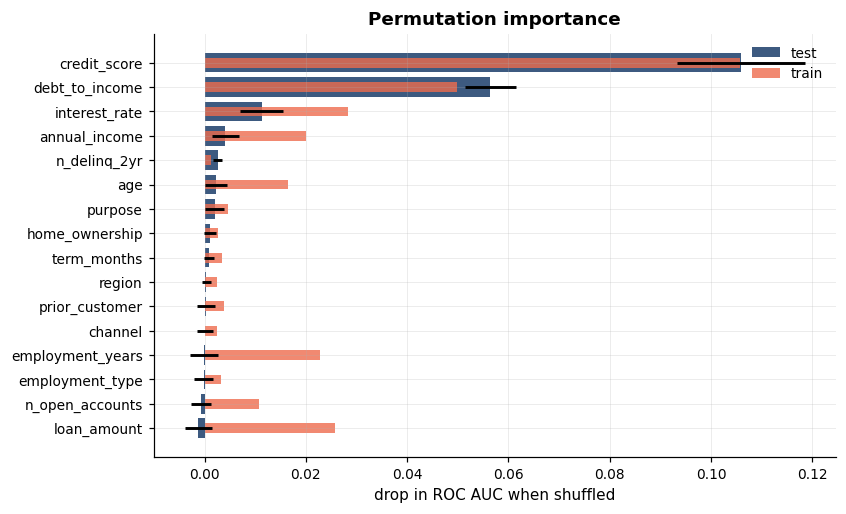

In [3]:
from sklearn.inspection import permutation_importance

perm_te = permutation_importance(boosted, X_te, y_te, n_repeats=10, random_state=0, scoring="roc_auc", n_jobs=-1)
perm_tr = permutation_importance(boosted, X_tr, y_tr, n_repeats=10, random_state=0, scoring="roc_auc", n_jobs=-1)

imp = pd.DataFrame({
    "test": perm_te.importances_mean,
    "test_std": perm_te.importances_std,
    "train": perm_tr.importances_mean,
}, index=X.columns).sort_values("test", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
order = imp.index[::-1]
ax.barh(order, imp.loc[order, "test"], xerr=imp.loc[order, "test_std"], color="#3d5a80", label="test")
ax.barh(order, imp.loc[order, "train"], height=0.4, color="#ee6c4d", alpha=0.8, label="train")
ax.set(xlabel="drop in ROC AUC when shuffled", title="Permutation importance")
ax.legend()
imp.round(4)

### The correlated-features failure

Permutation importance asks "what happens if this feature becomes noise, with
everything else intact?" If two features carry the same information, shuffling
either one costs nothing — the model reads the other. **Both appear
unimportant, and together they may be the most important thing in the model.**

Demonstrated by duplicating a column:

> ⚠️ **A real bug worth meeting once.** `Pipeline` does **not** clone its
> steps — it fits the objects you handed it. So reusing one `prep` instance in
> two pipelines means the second `fit` silently re-fits the first pipeline's
> preprocessing. Here that would leave `boosted` expecting a column that only
> exists in the duplicated frame. Pass `clone(prep)`, or build a fresh one.
> (`cross_val_score`, `GridSearchCV` and friends clone the whole estimator, so
> this only bites when you fit pipelines directly — which is exactly what you
> do when producing final artefacts.)

In [4]:
from sklearn.base import clone

X_dup = X.copy()
X_dup["credit_score_copy"] = X["credit_score"] * 1.0 + rng.normal(0, 1, len(X))   # near-duplicate

Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(X_dup, y, test_size=0.3, stratify=y, random_state=0)
dup_model = Pipeline([("prep", clone(prep)), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=300, learning_rate=0.06))]).fit(Xd_tr, yd_tr)
perm_dup = permutation_importance(dup_model, Xd_te, yd_te, n_repeats=10, random_state=0, scoring="roc_auc", n_jobs=-1)

pd.DataFrame({
    "with a duplicate present": pd.Series(perm_dup.importances_mean, index=X_dup.columns),
    "original model": pd.Series(perm_te.importances_mean, index=X.columns),
}).loc[["credit_score", "credit_score_copy", "interest_rate", "debt_to_income"]].round(4)

,with a duplicate present,original model
credit_score,0.0461,0.1059
credit_score_copy,0.0287,NaN
interest_rate,0.0098,0.0113
debt_to_income,0.0591,0.0564


`credit_score`'s importance collapses the moment a near-copy exists. Nothing
about the model's reliance on that information changed — only our ability to
measure it one column at a time.

**The fix: permute correlated features together.** Cluster features by
correlation, then shuffle whole clusters.

{'group_3': ['annual_income', 'loan_amount'],
 'group_5': ['interest_rate', 'credit_score', 'credit_score_copy'],
 'group_6': ['term_months', 'debt_to_income']}

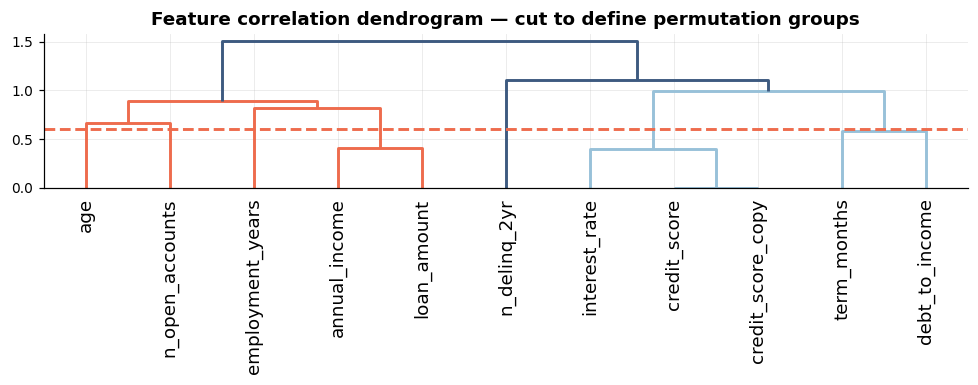

In [5]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr

num_cols = X_dup.select_dtypes(include=np.number).columns
corr = spearmanr(X_dup[num_cols].fillna(X_dup[num_cols].median())).correlation
corr = (corr + corr.T) / 2
np.fill_diagonal(corr, 1.0)
dist_linkage = hierarchy.ward(squareform(np.clip(1 - np.abs(corr), 0, None)))

fig, ax = plt.subplots(figsize=(9, 3.6))
dendro = hierarchy.dendrogram(dist_linkage, labels=list(num_cols), ax=ax, leaf_rotation=90)
ax.axhline(0.6, ls="--", color="#ee6c4d")
ax.set_title("Feature correlation dendrogram — cut to define permutation groups")
plt.tight_layout()

cluster_ids = hierarchy.fcluster(dist_linkage, 0.6, criterion="distance")
groups = pd.Series(cluster_ids, index=num_cols).groupby(lambda c: cluster_ids[list(num_cols).index(c)]).groups
grouped = {f"group_{k}": list(v) for k, v in pd.Series(num_cols).groupby(cluster_ids).apply(list).items()}
{k: v for k, v in grouped.items() if len(v) > 1}

In [6]:
def grouped_permutation_importance(model, X, y, feature_groups, scoring=roc_auc_score, n_repeats=5, seed=0):
    """Shuffle whole groups of correlated features together."""
    rs = np.random.default_rng(seed)
    baseline = scoring(y, model.predict_proba(X)[:, 1])
    out = {}
    for name, cols in feature_groups.items():
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            perm = rs.permutation(len(Xp))
            for c in cols:
                Xp[c] = Xp[c].to_numpy()[perm]        # SAME permutation for the whole group
            drops.append(baseline - scoring(y, model.predict_proba(Xp)[:, 1]))
        out[name] = np.mean(drops)
    return pd.Series(out).sort_values(ascending=False)


gi = grouped_permutation_importance(dup_model, Xd_te, yd_te, grouped)
pd.DataFrame({"grouped_importance": gi.round(4), "members": [", ".join(grouped[k]) for k in gi.index]})

,grouped_importance,members
group_5,0.1584,"interest_rate, credit_score, credit_score_copy"
group_6,0.0484,"term_months, debt_to_income"
group_3,0.0040,"annual_income, loan_amount"
group_1,0.0031,age
group_7,0.0018,n_delinq_2yr
group_4,-0.0015,employment_years
group_2,-0.0035,n_open_accounts


The group containing `credit_score` and its copy now shows its true worth.

> 💼 **Consulting lens.** "Feature X is not important" is one of the most
> frequently wrong claims in model documentation, and the cause is almost
> always this. Before accepting it, ask: *is anything else in the model
> correlated with X?* If yes, the single-feature number is uninterpretable.

## 3. Partial dependence and ICE

PDP shows the average predicted response as one feature varies, marginalising
over everything else. ICE shows the same curve **per individual**. Plot both —
the average can hide opposite effects in different subpopulations.

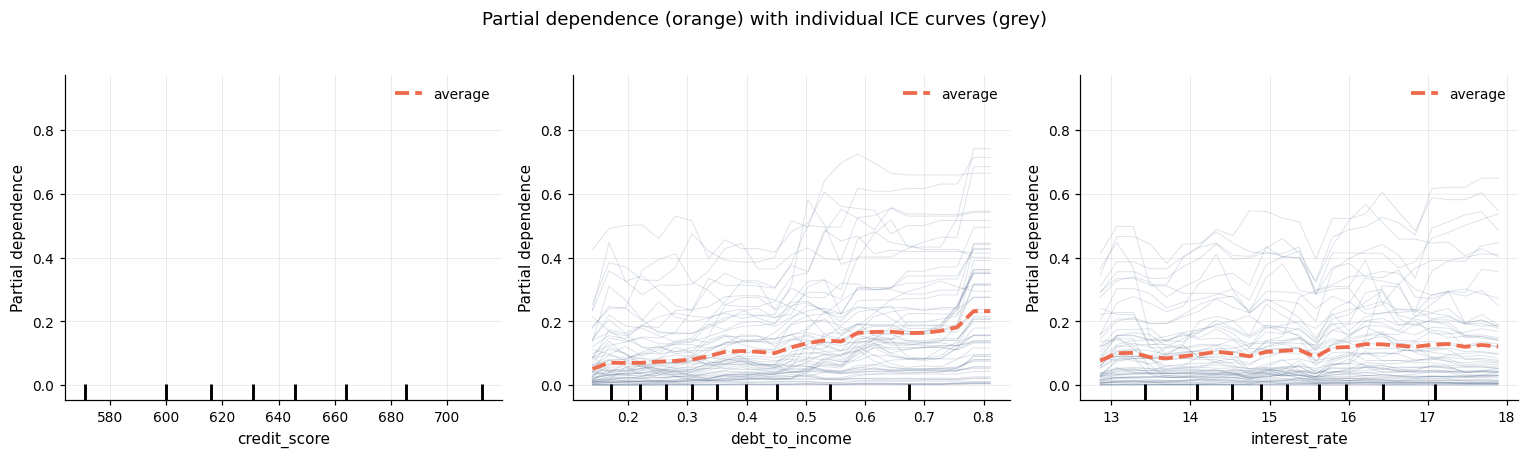

In [7]:
from sklearn.inspection import PartialDependenceDisplay

# PD is O(n_rows x grid_resolution) model calls per feature, so sample.
X_pd = X_te.sample(1200, random_state=0)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    boosted, X_pd, features=["credit_score", "debt_to_income", "interest_rate"],
    kind="both", subsample=60, grid_resolution=25, ax=ax, random_state=0,
    ice_lines_kw={"alpha": 0.18, "linewidth": 0.6}, pd_line_kw={"color": "#ee6c4d", "linewidth": 2.5},
)
fig.suptitle("Partial dependence (orange) with individual ICE curves (grey)", y=1.03)
plt.tight_layout()

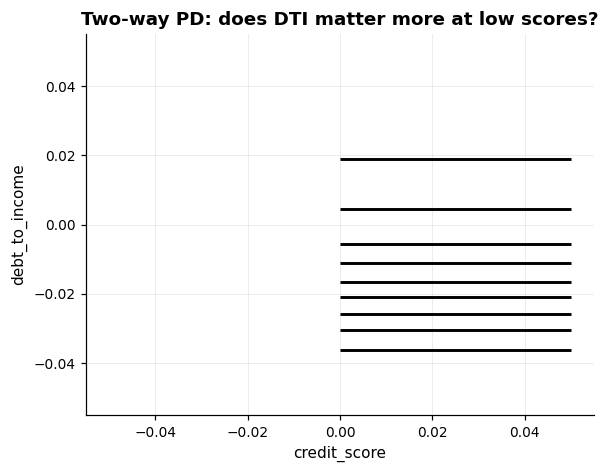

In [8]:
# Two-way partial dependence: interactions.
fig, ax = plt.subplots(figsize=(5.6, 4.4))
# A two-way grid is quadratic: 20 x 20 x 1,200 rows is already 480,000 model calls.
PartialDependenceDisplay.from_estimator(
    boosted, X_pd.sample(600, random_state=0), features=[("credit_score", "debt_to_income")],
    grid_resolution=18, ax=ax,
)
ax.set_title("Two-way PD: does DTI matter more at low scores?")
plt.tight_layout()

### The assumption PDP makes, and when it breaks

To compute the PDP at `credit_score = 800`, sklearn sets *every* row's
`credit_score` to 800 and averages the predictions — including rows with
`interest_rate = 22%`, a combination that does not exist in reality (the
lender prices off the score). **The PDP is therefore partly an average over
impossible applicants.**

Diagnose it by checking how much of the plotted range is actually populated:

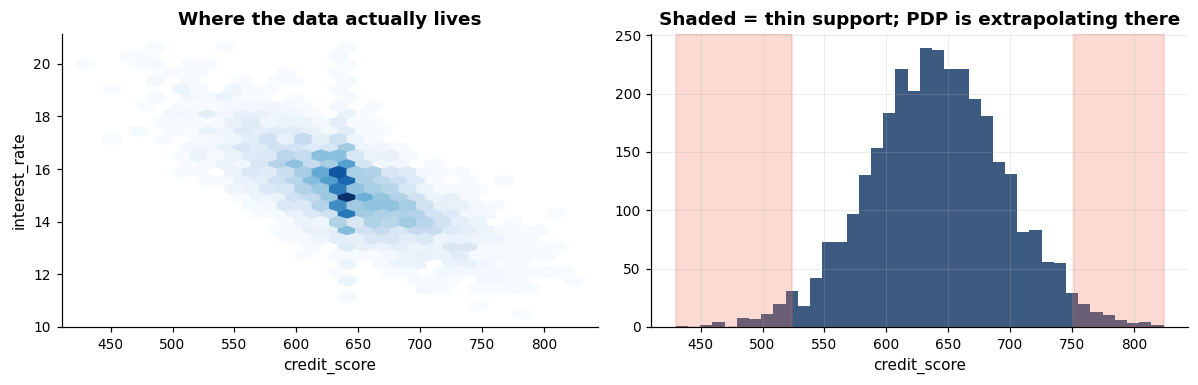

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hexbin(X_te["credit_score"].fillna(X_te["credit_score"].median()), X_te["interest_rate"], gridsize=28, cmap="Blues", mincnt=1)
axes[0].set(xlabel="credit_score", ylabel="interest_rate", title="Where the data actually lives")
axes[0].grid(False)

# The deciles PDP averages over -- shaded where support is thin.
support = X_te["credit_score"].dropna()
axes[1].hist(support, bins=40, color="#3d5a80")
lo, hi = support.quantile([0.02, 0.98])
axes[1].axvspan(support.min(), lo, color="#ee6c4d", alpha=0.25)
axes[1].axvspan(hi, support.max(), color="#ee6c4d", alpha=0.25)
axes[1].set(xlabel="credit_score", title="Shaded = thin support; PDP is extrapolating there")
plt.tight_layout()

Two practical rules:

1. **Never read a PDP outside the 5th–95th percentile of the feature.** That
   part of the curve is extrapolation dressed as evidence.
2. **When features are strongly dependent, prefer ALE plots** (accumulated
   local effects), which condition on the local neighbourhood instead of
   marginalising. sklearn does not ship ALE; the `alibi` and `PyALE` packages
   do.

## 4. SHAP

SHAP allocates a prediction among its features using the Shapley value from
cooperative game theory. Its selling point is the **additivity guarantee**:

$$ f(x) = \phi_0 + \sum_j \phi_j $$

The prediction equals the base value plus the contributions. That property is
what makes it usable in a decline letter — the numbers add up to the decision.

In [10]:
import shap

# TreeExplainer is exact and fast for tree ensembles; use it whenever you can.
X_te_prep = pd.DataFrame(boosted[:-1].transform(X_te), columns=boosted[:-1].get_feature_names_out())
explainer = shap.TreeExplainer(boosted.named_steps["clf"])
sv = explainer(X_te_prep.iloc[:800])

print(f"base value (log-odds): {sv.base_values[0]:.4f}")
print("additivity check on row 0:")
print(f"  base + sum(shap) = {sv.base_values[0] + sv.values[0].sum():.6f}")
raw = boosted.named_steps["clf"].decision_function(X_te_prep.iloc[:1])[0]
print(f"  model output     = {raw:.6f}")

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


base value (log-odds): -2.8723
additivity check on row 0:
  base + sum(shap) = -3.253833
  model output     = -3.253833


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(


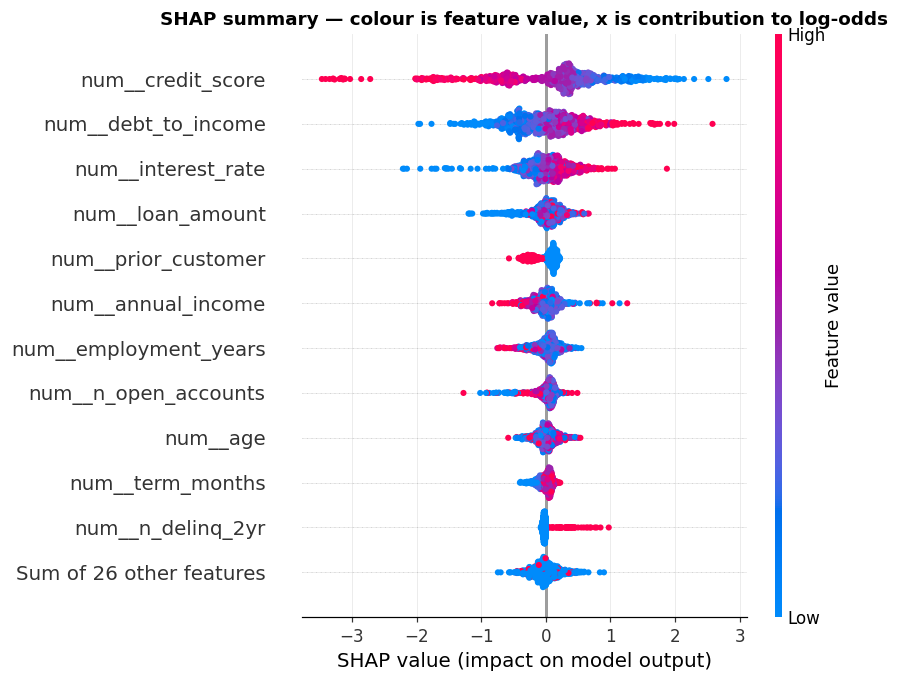

In [11]:
# Global view: mean |SHAP| per feature, and the beeswarm showing direction.
fig = plt.figure(figsize=(8, 5))
shap.plots.beeswarm(sv, max_display=12, show=False)
plt.title("SHAP summary — colour is feature value, x is contribution to log-odds")
plt.tight_layout()

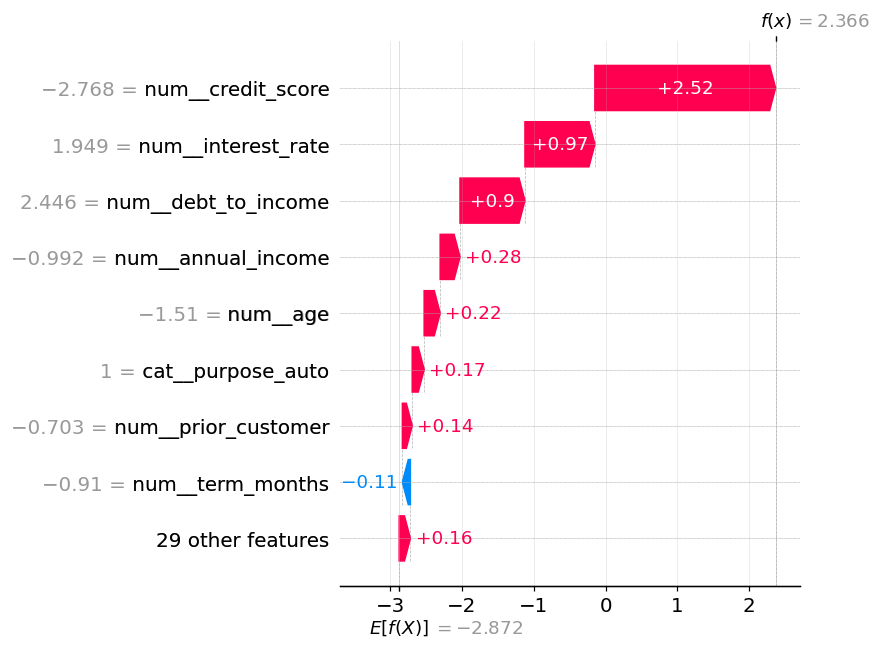

In [12]:
# Local view: one applicant's decision, decomposed.
i = int(np.argmax(sv.values.sum(1)))         # the highest-risk applicant in the sample
fig = plt.figure(figsize=(8, 4.5))
shap.plots.waterfall(sv[i], max_display=9, show=False)
plt.tight_layout()

In [13]:
# The same thing as a table you could put in a letter.
contrib = (
    pd.Series(sv.values[i], index=X_te_prep.columns)
    .sort_values(key=np.abs, ascending=False)
    .head(6)
)
applicant = X_te.iloc[i]
pd.DataFrame({
    "contribution_to_log_odds": contrib.round(3),
    "direction": np.where(contrib > 0, "increases risk", "reduces risk"),
})

,contribution_to_log_odds,direction
num__credit_score,2.515,increases risk
num__interest_rate,0.973,increases risk
num__debt_to_income,0.903,increases risk
num__annual_income,0.276,increases risk
num__age,0.223,increases risk
cat__purpose_auto,0.166,increases risk


### SHAP's own caveats, which are rarely stated

1. **Correlated features again.** Shapley values distribute credit among
   *coalitions* of features. With correlated inputs, the default
   (interventional) `TreeExplainer` evaluates the model on combinations that
   never occur, exactly like PDP. `feature_perturbation="tree_path_dependent"`
   conditions on the data instead — different numbers, different meaning.
   Know which you are using.
2. **The base value depends on the background set.** Contributions are relative
   to it, so an explanation computed against the whole portfolio and one
   computed against a segment are not comparable.
3. **"Contribution" is not "cause".** SHAP explains the *model*, not the world.
   If the model is wrong, SHAP faithfully explains a wrong thing.
4. **`KernelExplainer` is an approximation** and is slow. Use `TreeExplainer`
   for trees and `LinearExplainer` for linear models; only fall back to Kernel
   when you must.

For a linear model, SHAP has a closed form and equals `coef * (x - E[x])` —
which is a useful sanity check on your understanding:

In [14]:
X_lin_prep = pd.DataFrame(linear[:-1].transform(X_te), columns=linear[:-1].get_feature_names_out())
lin_explainer = shap.LinearExplainer(linear.named_steps["clf"], X_lin_prep)
sv_lin = lin_explainer(X_lin_prep.iloc[:200])

coefs = linear.named_steps["clf"].coef_.ravel()
manual = (X_lin_prep.iloc[:200].to_numpy() - X_lin_prep.to_numpy().mean(0)) * coefs

corr = np.corrcoef(sv_lin.values.ravel(), manual.ravel())[0, 1]
print(f"correlation with coef*(x − mean) : {corr:.6f}")
print(f"max absolute difference          : {np.abs(sv_lin.values - manual).max():.4f}")
print(f"typical |shap| for scale          : {np.abs(sv_lin.values).mean():.4f}")
print("\nEssentially the same object. The residual difference is the correlation")
print("correction: LinearExplainer's default masker accounts for covariance")
print("between features, whereas coef*(x − mean) assumes independence.")
print("For a linear model, SHAP adds almost nothing the coefficients did not say.")

correlation with coef*(x − mean) : 0.995330
max absolute difference          : 0.0571
typical |shap| for scale          : 0.0527

Essentially the same object. The residual difference is the correlation
correction: LinearExplainer's default masker accounts for covariance
between features, whereas coef*(x − mean) assumes independence.
For a linear model, SHAP adds almost nothing the coefficients did not say.


## 5. Surrogate models

Fit a small interpretable model to the *predictions* of the complex one. It
gives you a readable global story — provided you report the **fidelity**, which
almost nobody does.

In [15]:
from sklearn.tree import DecisionTreeRegressor, export_text

surrogate_target = boosted.predict_proba(X_tr)[:, 1]
X_tr_prep = pd.DataFrame(boosted[:-1].transform(X_tr), columns=boosted[:-1].get_feature_names_out())

for depth in [2, 3, 4, 6]:
    sur = DecisionTreeRegressor(max_depth=depth, random_state=0).fit(X_tr_prep, surrogate_target)
    fid = sur.score(pd.DataFrame(boosted[:-1].transform(X_te), columns=X_tr_prep.columns), boosted.predict_proba(X_te)[:, 1])
    print(f"depth {depth}: surrogate R² vs the real model on held-out data = {fid:.3f}")

depth 2: surrogate R² vs the real model on held-out data = 0.537


depth 3: surrogate R² vs the real model on held-out data = 0.649
depth 4: surrogate R² vs the real model on held-out data = 0.674
depth 6: surrogate R² vs the real model on held-out data = 0.664


In [16]:
sur = DecisionTreeRegressor(max_depth=3, random_state=0).fit(X_tr_prep, surrogate_target)
print(export_text(sur, feature_names=list(X_tr_prep.columns), decimals=3, max_depth=3)[:1600])

|--- num__credit_score <= -1.131
|   |--- num__debt_to_income <= 1.297
|   |   |--- num__debt_to_income <= -0.160
|   |   |   |--- value: [0.191]
|   |   |--- num__debt_to_income >  -0.160
|   |   |   |--- value: [0.333]
|   |--- num__debt_to_income >  1.297
|   |   |--- num__debt_to_income <= 2.776
|   |   |   |--- value: [0.496]
|   |   |--- num__debt_to_income >  2.776
|   |   |   |--- value: [0.751]
|--- num__credit_score >  -1.131
|   |--- num__debt_to_income <= 0.936
|   |   |--- num__credit_score <= 0.084
|   |   |   |--- value: [0.117]
|   |   |--- num__credit_score >  0.084
|   |   |   |--- value: [0.044]
|   |--- num__debt_to_income >  0.936
|   |   |--- num__interest_rate <= 2.393
|   |   |   |--- value: [0.233]
|   |   |--- num__interest_rate >  2.393
|   |   |   |--- value: [0.716]



**Read the fidelity numbers, and notice they are not good.** A depth-3
surrogate explains about 65% of the variance in the model's predictions, and
going deeper barely helps — depth 6 is no better than depth 4. A third of what
the model does is not captured by any small tree.

That is the honest result, and it is the reason the fidelity number must
always be published with the surrogate. Presented alone, this tree reads as
"here is what the model does" and invites a committee to believe the model is
a handful of rules. Presented as "here is a depth-3 approximation that agrees
with the model 65% of the time", it becomes what it actually is: a useful
summary and an admission that the real model is doing something more.

If your surrogate reaches R² above ~0.95, the interesting question is why you
are not simply shipping the surrogate.

## 6. Fairness

Age is a protected characteristic under fair-lending rules in most
jurisdictions, and geography is a standard redlining concern. Neither is
optional to check.

The first thing to understand is that **"fairness" is several mutually
incompatible definitions**, and you must choose.

In [17]:
groups = pd.DataFrame({
    "age_band": pd.cut(X_te["age"], [18, 30, 45, 60, 100], labels=["19-30", "31-45", "46-60", "60+"]),
    "region": X_te["region"].to_numpy(),
})
scores_te = boosted.predict_proba(X_te)[:, 1]
THRESHOLD = 0.13        # roughly the cost-optimal threshold from Module 08


def fairness_table(y_true, y_score, group, threshold=THRESHOLD):
    pred = (y_score >= threshold).astype(int)
    rows = []
    for g in pd.Series(group).dropna().unique():
        m = (pd.Series(group).to_numpy() == g)
        yt, yp, ys = np.asarray(y_true)[m], pred[m], y_score[m]
        pos = yt == 1
        rows.append({
            "group": g,
            "n": int(m.sum()),
            "base_rate": yt.mean(),
            "selection_rate": yp.mean(),                                  # demographic parity
            "TPR": yp[pos].mean() if pos.any() else np.nan,               # equal opportunity
            "FPR": yp[~pos].mean() if (~pos).any() else np.nan,           # equalised odds (with TPR)
            "precision": yt[yp == 1].mean() if (yp == 1).any() else np.nan,
            "mean_pred": ys.mean(),                                       # calibration by group
            "auc": roc_auc_score(yt, ys) if len(np.unique(yt)) > 1 else np.nan,
        })
    out = pd.DataFrame(rows).set_index("group").sort_index()
    return out.round(4)


ft_age = fairness_table(y_te, scores_te, groups["age_band"])
ft_age

,n,base_rate,selection_rate,TPR,FPR,precision,mean_pred,auc
group,,,,,,,,
19-30,880,0.1455,0.3284,0.6328,0.2766,0.2803,0.1383,0.7247
31-45,1784,0.1306,0.2747,0.6137,0.2237,0.2918,0.1162,0.7554
46-60,738,0.1274,0.2114,0.5532,0.1615,0.3333,0.1055,0.7974
60+,198,0.1111,0.1414,0.4091,0.1080,0.3214,0.0796,0.6901


In [18]:
ft_region = fairness_table(y_te, scores_te, groups["region"])
ft_region

,n,base_rate,selection_rate,TPR,FPR,precision,mean_pred,auc
group,,,,,,,,
midwest,759,0.1462,0.2754,0.5495,0.2284,0.2919,0.1235,0.7256
northeast,738,0.1314,0.2737,0.5670,0.2293,0.2723,0.1145,0.7170
south,1341,0.1268,0.2565,0.6471,0.1998,0.3198,0.1170,0.7859
west,762,0.1299,0.2730,0.5960,0.2247,0.2837,0.1149,0.7543


### The four definitions, and what each demands

| Criterion | Requires equal across groups | Ignores |
|---|---|---|
| **Demographic parity** | `selection_rate` | whether the groups actually differ in risk |
| **Equal opportunity** | `TPR` (recall on the positive class) | false positives |
| **Equalised odds** | `TPR` **and** `FPR` | base-rate differences |
| **Calibration by group** | `mean_pred` matching `base_rate` in each group | error rates |

**The impossibility result** (Kleinberg–Mullainathan–Raghavan; Chouldechova,
2016): when the true base rates differ between groups, no non-trivial
classifier can satisfy calibration and equalised odds simultaneously. This is
arithmetic, not a modelling shortcoming. **You must choose which fairness
criterion your problem requires**, and be able to say why.

In lending, calibration by group is usually non-negotiable — an uncalibrated
model prices one group's risk wrongly, which is itself the harm — so the
realistic target is calibration plus a bounded disparity in outcomes, plus
documented justification for the residual gap.

In [19]:
# Quantify the disparities, with the two standard summary ratios.
def disparity(table):
    return pd.Series({
        "selection_rate_ratio (4/5ths rule)": table["selection_rate"].min() / table["selection_rate"].max(),
        "TPR_difference": table["TPR"].max() - table["TPR"].min(),
        "FPR_difference": table["FPR"].max() - table["FPR"].min(),
        "calibration_gap": (table["mean_pred"] - table["base_rate"]).abs().max(),
        "AUC_range": table["auc"].max() - table["auc"].min(),
    }).round(4)


pd.DataFrame({"by age_band": disparity(ft_age), "by region": disparity(ft_region)})

,by age_band,by region
selection_rate_ratio (4/5ths rule),0.4306,0.9314
TPR_difference,0.2237,0.0976
FPR_difference,0.1686,0.0295
calibration_gap,0.0315,0.0227
AUC_range,0.1073,0.0689


The **four-fifths rule** (US EEOC guidance, widely used as a screening test):
a selection-rate ratio below 0.8 is prima facie evidence of adverse impact and
requires justification. It is a screen, not a verdict — but it is the number a
regulator will compute first, so compute it yourself.

### Proxies: removing the attribute does not remove the effect

"We do not use age in the model" is not a defence if three other features
jointly predict age. Test it directly: **can you predict the protected
attribute from the features you are using?**

In [20]:
from sklearn.model_selection import cross_val_score

proxy_target = (X["age"] >= 60).astype(int)
proxy_X = X.drop(columns=["age"])

proxy_auc = cross_val_score(
    Pipeline([("prep", clone(prep)), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=200))]),
    proxy_X, proxy_target, cv=4, scoring="roc_auc", n_jobs=-1,
).mean()
print(f"predicting 'age >= 60' from the OTHER features: AUC {proxy_auc:.4f}")
print("(0.5 = age is unrecoverable; 1.0 = age is fully encoded in the other features)")

predicting 'age >= 60' from the OTHER features: AUC 0.8202
(0.5 = age is unrecoverable; 1.0 = age is fully encoded in the other features)


In [21]:
# Which features carry the proxy information?
proxy_model = Pipeline([("prep", clone(prep)), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=200))]).fit(proxy_X, proxy_target)
proxy_imp = permutation_importance(proxy_model, proxy_X.iloc[:4000], proxy_target.iloc[:4000],
                                   n_repeats=5, random_state=0, scoring="roc_auc", n_jobs=-1)
pd.Series(proxy_imp.importances_mean, index=proxy_X.columns).sort_values(ascending=False).head(6).round(4).to_frame("proxy_strength")

,proxy_strength
annual_income,0.1910
n_open_accounts,0.0837
employment_years,0.0429
credit_score,0.0392
loan_amount,0.0223
debt_to_income,0.0218


> 💼 **Consulting lens.** This is the single most useful fairness diagnostic
> and it takes four lines. If the protected attribute is recoverable from your
> feature set with AUC 0.85, then "we do not use it" is a statement about your
> schema, not about your model's behaviour. Run this before anyone claims the
> model is attribute-blind.

### Mitigation, in order of how much I trust it

1. **Fix the data.** Disparities usually originate upstream — in who was
   offered credit historically, whose outcomes were recorded, and how. No
   post-processing repairs a biased sample.
2. **Monotonic constraints and simpler models** (Module 06). They make
   behaviour predictable and reviewable, which is most of what a regulator
   wants.
3. **Group-specific thresholds.** Effective and often *legally prohibited* —
   in US lending, setting a different cut-off by protected group is generally
   disparate treatment. Know the jurisdiction before proposing it.
4. **In-processing constraints** (`fairlearn`'s `ExponentiatedGradient`,
   reductions approaches). Principled, and they change the model, which means
   re-validating everything.
5. **Removing the attribute.** Nearly useless on its own, per the proxy test
   above — and it removes your ability to *measure* the disparity, which makes
   things worse rather than better.

In [22]:
# Illustrating (3) and why it is tempting: equalising TPR by group threshold.
def thresholds_for_equal_tpr(y_true, y_score, group, target_tpr=0.55):
    out = {}
    for g in pd.Series(group).dropna().unique():
        m = pd.Series(group).to_numpy() == g
        yt, ys = np.asarray(y_true)[m], y_score[m]
        pos = ys[yt == 1]
        out[g] = np.quantile(pos, 1 - target_tpr) if len(pos) else np.nan
    return pd.Series(out)


thr = thresholds_for_equal_tpr(y_te, scores_te, groups["age_band"])
adjusted = np.zeros(len(y_te), dtype=int)
for g, t in thr.items():
    m = groups["age_band"].to_numpy() == g
    adjusted[m] = (scores_te[m] >= t).astype(int)

comparison = pd.DataFrame({
    "single threshold TPR": ft_age["TPR"],
    "group threshold": thr.round(4),
    "group threshold TPR": pd.Series({
        g: adjusted[(groups["age_band"].to_numpy() == g) & (y_te.to_numpy() == 1)].mean()
        for g in thr.index
    }).round(4),
}).sort_index()
comparison

,single threshold TPR,group threshold,group threshold TPR
19-30,0.6328,0.1798,0.5469
31-45,0.6137,0.1583,0.5494
46-60,0.5532,0.1349,0.5532
60+,0.4091,0.0457,0.5455


TPR is now equal by construction — and the thresholds differ by group, which
in most lending jurisdictions is exactly the thing you are not allowed to do.
**A technically clean fairness intervention can be legally impermissible.**
This is why fairness work in regulated industries needs legal input early, not
as a review at the end.

## 7. The model card

Everything above is only useful if it is written down in a form someone can
check. This is the minimum.

In [23]:
def model_card(model, X_tr, y_tr, X_te, y_te, name, fairness_tables=None):
    from sklearn.metrics import average_precision_score, brier_score_loss

    p = model.predict_proba(X_te)[:, 1]
    lines = [
        f"# Model card — {name}",
        "",
        "## Intended use",
        "  Rank consumer loan applications by 36-month default risk, to support",
        "  (not replace) an underwriting decision. NOT validated for pricing,",
        "  provisioning, or any population other than the one described below.",
        "",
        "## Data",
        f"  training rows        : {len(X_tr):,}",
        f"  evaluation rows      : {len(X_te):,}",
        f"  features             : {X_tr.shape[1]}",
        f"  training base rate   : {y_tr.mean():.4f}",
        f"  evaluation base rate : {y_te.mean():.4f}",
        "",
        "## Performance",
        f"  ROC AUC              : {roc_auc_score(y_te, p):.4f}",
        f"  Average precision    : {average_precision_score(y_te, p):.4f}",
        f"  Brier score          : {brier_score_loss(y_te, p):.5f}",
        f"  Mean predicted rate  : {p.mean():.4f}  (observed {y_te.mean():.4f})",
        "",
        "## Architecture",
        f"  {' -> '.join(type(s).__name__ for _, s in model.steps)}",
        "",
        "## Known limitations",
        "  - Trained on 2022-2024 applications; a macro regime shift in the final",
        "    year means performance is not stationary (see Module 04).",
        "  - `interest_rate` was set by an existing risk-based pricing model, so it",
        "    is partly endogenous to the outcome being predicted.",
        "  - Applicants with no bureau score (thin file) are a distinct population;",
        "    the missingness indicator carries real signal.",
        "",
    ]
    if fairness_tables:
        lines.append("## Fairness")
        for attr, tbl in fairness_tables.items():
            ratio = tbl["selection_rate"].min() / tbl["selection_rate"].max()
            gap = (tbl["mean_pred"] - tbl["base_rate"]).abs().max()
            flag = "PASS" if ratio >= 0.8 else "REVIEW"
            lines.append(f"  {attr:<10} selection-rate ratio {ratio:.3f} [{flag}], "
                         f"max calibration gap {gap:.4f}, AUC range {tbl['auc'].max() - tbl['auc'].min():.3f}")
        lines.append("")
    lines += [
        "## Monitoring",
        "  - Monthly: ROC AUC, Brier, mean predicted vs observed rate, PSI on inputs.",
        "  - Alert if calibration gap > 0.02 or AUC drops > 0.03 from baseline.",
        "  - Re-run the fairness table quarterly and on every retrain.",
    ]
    return "\n".join(lines)


print(model_card(boosted, X_tr, y_tr, X_te, y_te, "Consumer default risk v1.0",
                 {"age_band": ft_age, "region": ft_region}))

# Model card — Consumer default risk v1.0

## Intended use
  Rank consumer loan applications by 36-month default risk, to support
  (not replace) an underwriting decision. NOT validated for pricing,
  provisioning, or any population other than the one described below.

## Data
  training rows        : 8,400
  evaluation rows      : 3,600
  features             : 16
  training base rate   : 0.1326
  evaluation base rate : 0.1325

## Performance
  ROC AUC              : 0.7518
  Average precision    : 0.4069
  Brier score          : 0.09850
  Mean predicted rate  : 0.1174  (observed 0.1325)

## Architecture
  ColumnTransformer -> HistGradientBoostingClassifier

## Known limitations
  - Trained on 2022-2024 applications; a macro regime shift in the final
    year means performance is not stationary (see Module 04).
  - `interest_rate` was set by an existing risk-based pricing model, so it
    is partly endogenous to the outcome being predicted.
  - Applicants with no bureau score (thin fi

---
## Exercises

### Exercise 12.1 — Five importance measures, one table

Build a dataset with 3 informative features, 3 noisy copies of them, 1
high-cardinality noise column and 3 low-cardinality noise columns. Compute:
impurity importance, permutation on train, permutation on test, grouped
permutation, drop-column importance, and mean |SHAP|.

Produce one table and one paragraph per method saying which decoy fooled it.
Then write the half-page guide you would give an analyst who has to present
importances to a committee.

In [24]:
# Your code here.

### Exercise 12.2 — PDP vs ALE

Implement ALE (accumulated local effects) for one numeric feature: bin the
feature, compute the *local* effect within each bin by moving points to the bin
edges, accumulate.

Compare PDP and ALE for `credit_score` and `interest_rate` — two features with
strong dependence by construction. Where do they disagree, and which would you
put in front of a regulator?

In [25]:
# Your code here.

### Exercise 12.3 — Adverse action notices

US fair-lending rules require a declined applicant to be told the principal
reasons. Build `adverse_action_reasons(model, applicant, top_k=4)` that:

1. Computes SHAP contributions for that applicant.
2. Keeps only the risk-*increasing* factors.
3. Maps feature names to plain-English reason codes.
4. Returns them ranked, with the counterfactual value that would have been
   needed for approval.

Test it on 10 declined applicants. Then critique your own output: are the
reasons *actionable*? Are any of them things the applicant cannot change?

In [26]:
# Your code here.

### Exercise 12.4 — The fairness–accuracy frontier

For the credit model, trace the trade-off:

1. Baseline: unconstrained, single threshold.
2. Remove `region` and every feature with proxy strength above a cut-off you
   choose. Re-measure AUC and disparity.
3. Apply monotonic constraints. Re-measure.
4. Use `fairlearn`'s `ExponentiatedGradient` with a demographic-parity
   constraint at several tolerance levels.

Plot AUC against selection-rate ratio for all of them. Identify the Pareto
frontier and recommend a point, with the reasoning you would give a fair-lending
committee.

In [27]:
# Your code here.

### Exercise 12.5 — Explain a model that is wrong

Train a model on the credit data **including** `collections_flag` — the
leakage column. It will score ~0.95 AUC.

1. Run the full interpretability suite on it: permutation importance, PDP,
   SHAP, surrogate tree.
2. Which of them makes the problem obvious? Which of them produce
   plausible-looking output that hides it?
3. Write the model card. Would your own card have caught it?

The lesson: interpretability tools explain the model faithfully, including
when the model is worthless. **They are not a substitute for understanding your
data lineage.**

In [28]:
# Your code here.

---
## Takeaways

- Pick the tool from the **question**: global reliance, local attribution,
  response shape, or group treatment.
- **Correlated features break single-feature importance.** Cluster and permute
  in groups. "Feature X is not important" is usually an artefact.
- PDP averages over combinations that may not exist. Never read it outside the
  5th–95th percentile; prefer ALE under strong dependence.
- SHAP's additivity makes it usable in a decline letter — but it explains the
  *model*, not the world, and it depends on the background set.
- Report **surrogate fidelity**, always. A tree without an R² invites false
  confidence.
- Fairness criteria are **mutually incompatible** when base rates differ. Choose
  deliberately and document why.
- Removing a protected attribute does not remove its influence. **Test whether
  you can predict it from the remaining features** — four lines, and the most
  informative fairness diagnostic there is.
- A technically clean fairness fix can be legally impermissible. Involve legal
  early.

**Next:** Module 13 — production: persistence, drift, monitoring, and the
things that break between the notebook and the service.